In [17]:
set.seed(123)

norm_data = read.csv("Data/Processed/nba_normal_scorers_filtered.csv")
# norm_data = norm_data[sample(nrow(norm_data), 900), ]

norm_data = subset(norm_data, select = -c(Player, Team, Pos, Awards, AllStarSelection, Rk))

norm_data = na.omit(norm_data)

n = floor(0.8 * nrow(norm_data))
index = sample(seq_len(nrow(norm_data)), size = n)

norm.train = norm_data[index, ]
norm.test = norm_data[-index, ]

head(norm.train)
summary(norm.train)

,Age,G,GS,MP,FG,FGA,FG.,X3P,X3PA,X3P.,⋯,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Year,Salary
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
511,32,55,7,17.3,2.2,5.2,0.433,0.7,1.5,0.439,⋯,1.3,1.6,2.4,0.6,0.2,1.2,1.0,6.7,2021,4110433
568,27,29,4,10.9,1.9,3.9,0.496,0.1,0.5,0.200,⋯,1.7,2.7,0.1,0.1,0.5,0.5,1.8,4.6,2021,2294633
209,24,37,12,24.5,1.8,4.4,0.414,0.6,1.9,0.324,⋯,1.8,2.3,2.1,1.1,0.1,0.8,1.6,4.6,2020,4906243
645,20,15,1,5.6,0.7,1.8,0.407,0.3,0.7,0.400,⋯,0.7,1.1,0.3,0.2,0.3,0.3,0.7,1.9,2021,1849950
229,25,42,5,13.5,1.3,3.2,0.406,0.9,2.6,0.351,⋯,1.7,2.6,0.4,0.1,0.5,0.2,1.1,3.7,2020,881609
1203,32,68,40,24.4,3.9,9.4,0.411,1.4,4.2,0.333,⋯,1.8,2.1,3.4,0.7,0.1,1.7,1.7,10.2,2023,12147949


      Age              G               GS              MP       
 Min.   :19.00   Min.   : 1.00   Min.   : 0.00   Min.   : 2.00  
 1st Qu.:22.00   1st Qu.:24.00   1st Qu.: 0.00   1st Qu.:12.03  
 Median :24.00   Median :48.00   Median : 5.00   Median :17.95  
 Mean   :25.46   Mean   :44.33   Mean   :18.51   Mean   :18.79  
 3rd Qu.:28.00   3rd Qu.:65.00   3rd Qu.:31.00   3rd Qu.:25.80  
 Max.   :43.00   Max.   :84.00   Max.   :83.00   Max.   :43.50  
       FG             FGA              FG.              X3P        
 Min.   :0.000   Min.   : 0.500   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:1.400   1st Qu.: 3.400   1st Qu.:0.3990   1st Qu.:0.3000  
 Median :2.500   Median : 5.600   Median :0.4400   Median :0.7000  
 Mean   :2.947   Mean   : 6.499   Mean   :0.4456   Mean   :0.9073  
 3rd Qu.:4.000   3rd Qu.: 8.600   3rd Qu.:0.4920   3rd Qu.:1.3000  
 Max.   :8.800   Max.   :19.400   Max.   :0.7470   Max.   :4.0000  
      X3PA            X3P.             X2P             X2PA       
 M

Predicting Salary (Main Use Case)


Call:
lm(formula = Salary ~ Age + MP + FG + X3P + AST + DRB + STL + 
    BLK + PTS + Year, data = norm.train)

Residuals:
      Min        1Q    Median        3Q       Max 
-19706912  -3631568   -358906   3070033  31216313 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -253318374  268690959  -0.943  0.34599    
Age             729727      44561  16.376  < 2e-16 ***
MP             -194837      63094  -3.088  0.00206 ** 
FG            -2466796     798518  -3.089  0.00205 ** 
X3P            -252618     466156  -0.542  0.58798    
AST            1341185     186236   7.202 1.07e-12 ***
DRB            1064035     228408   4.658 3.55e-06 ***
STL             536512     814077   0.659  0.51000    
BLK            1484054     634698   2.338  0.01955 *  
PTS            1721301     314392   5.475 5.36e-08 ***
Year            115460     132853   0.869  0.38498    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6362000

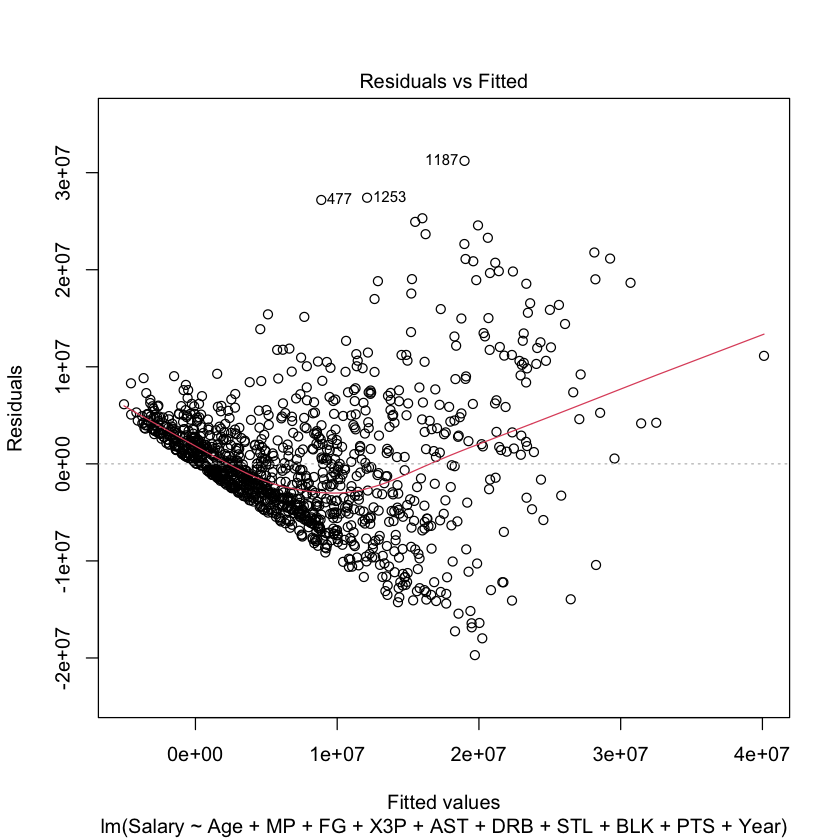

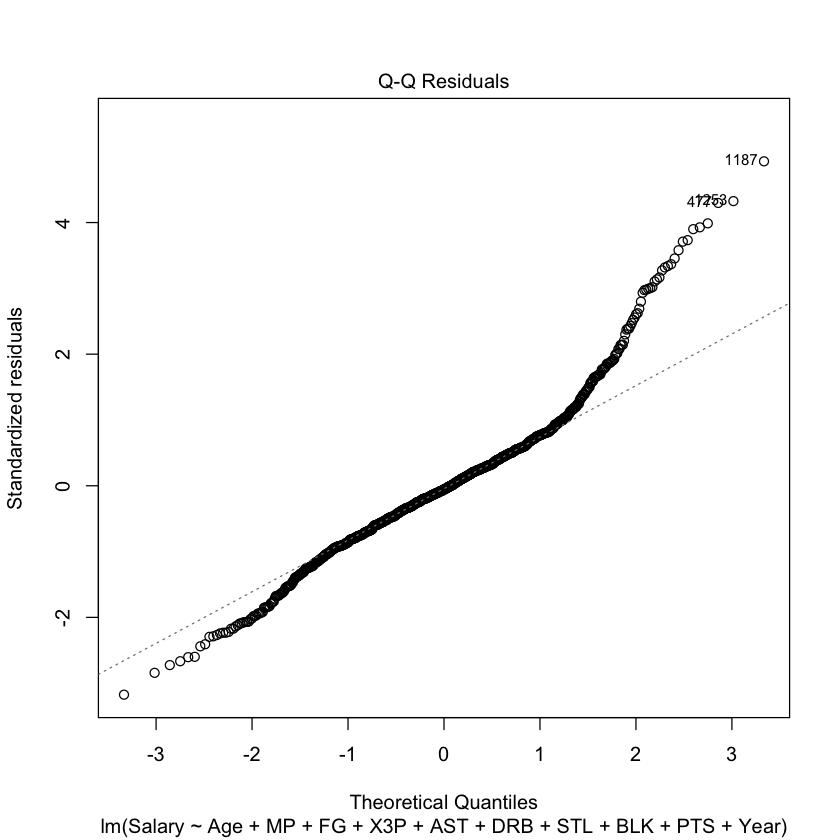

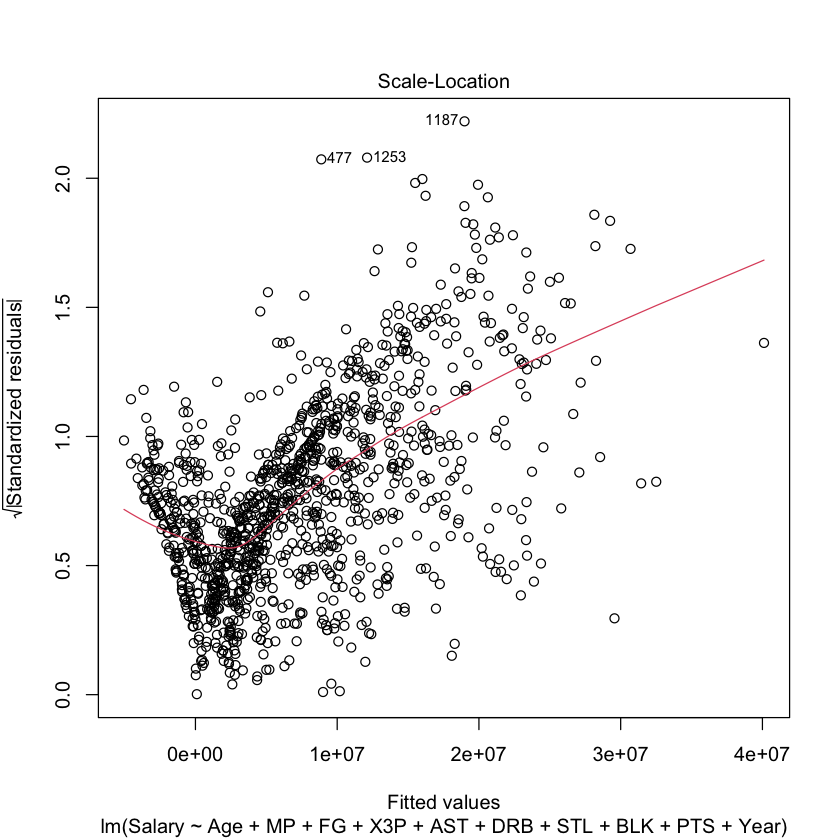

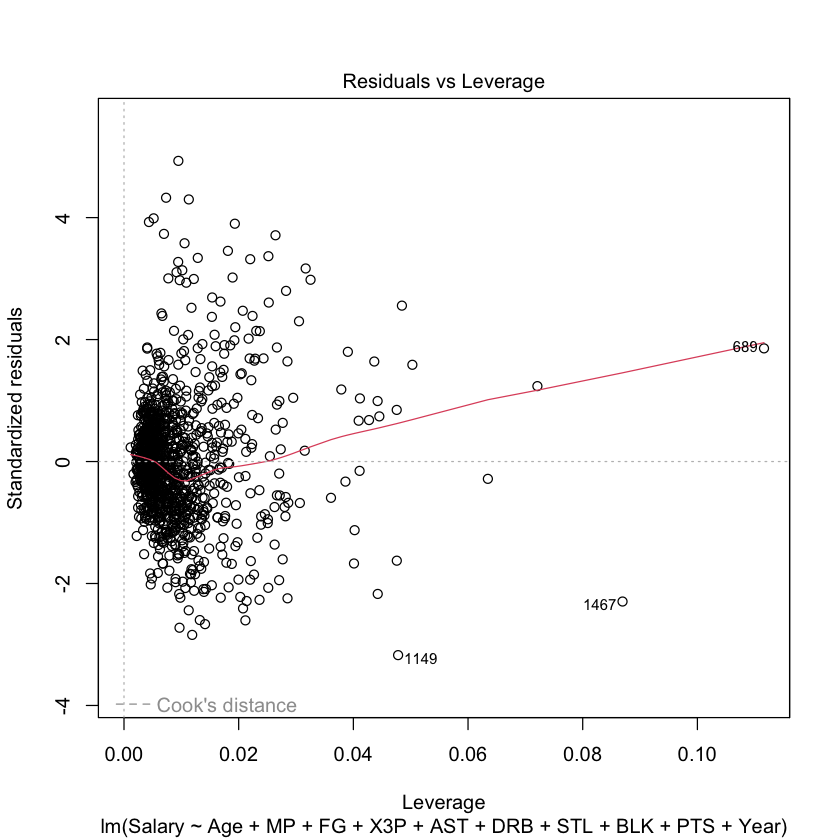

In [21]:
mod1 = lm(Salary ~ Age + MP + FG + X3P + AST + DRB + STL + BLK + PTS + Year, data = norm.train)
summary(mod1)
# par(mfrow = c(2, 2))
plot(mod1)

Predicting Points Scored (PTS)


Call:
lm(formula = PTS ~ MP + FGA + X3PA + FTA + TOV + AST, data = norm.train)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.8619 -0.4379  0.0159  0.4592  5.7494 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.559923   0.061790  -9.062  < 2e-16 ***
MP           0.062253   0.006428   9.684  < 2e-16 ***
FGA          1.004953   0.019521  51.480  < 2e-16 ***
X3PA        -0.015584   0.022693  -0.687  0.49237    
FTA          0.874837   0.035417  24.701  < 2e-16 ***
TOV         -0.327333   0.077787  -4.208 2.77e-05 ***
AST         -0.077344   0.025675  -3.012  0.00265 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8312 on 1163 degrees of freedom
Multiple R-squared:  0.9755,	Adjusted R-squared:  0.9754 
F-statistic:  7726 on 6 and 1163 DF,  p-value: < 2.2e-16


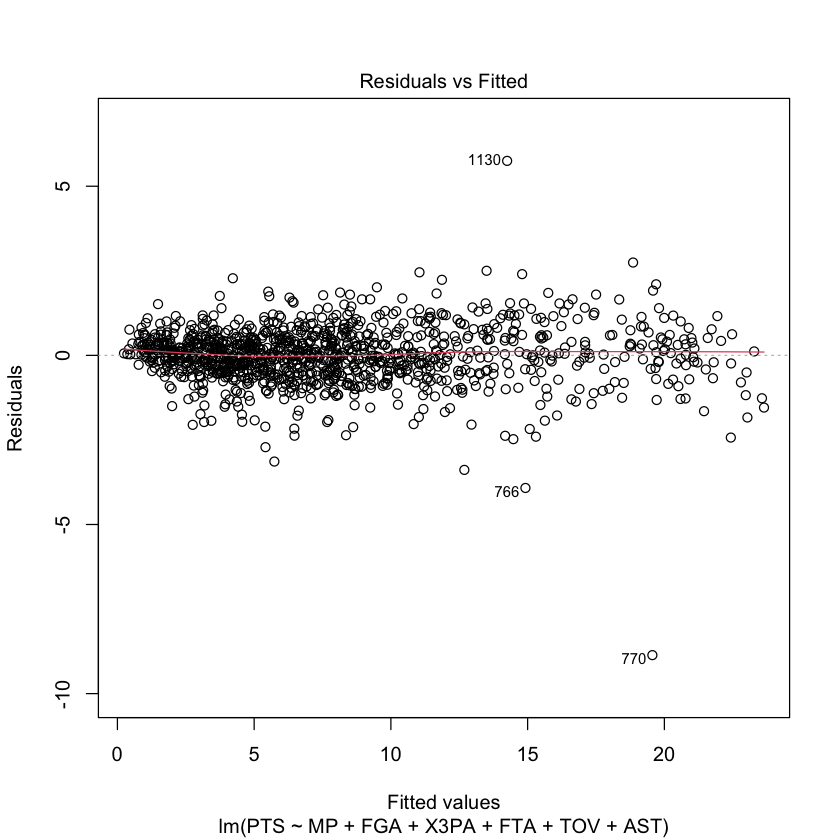

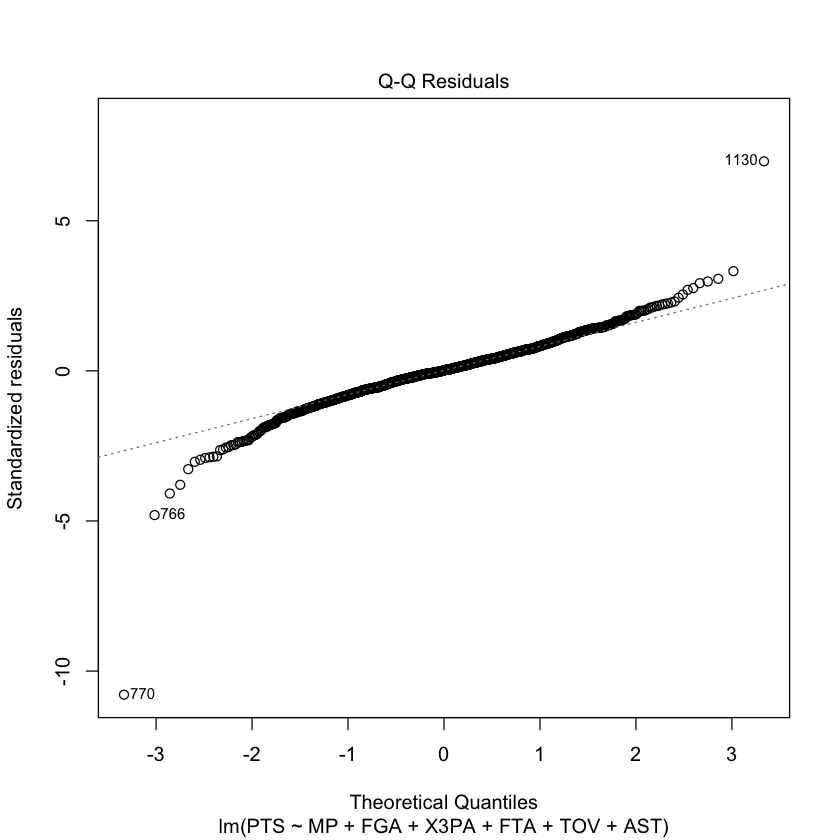

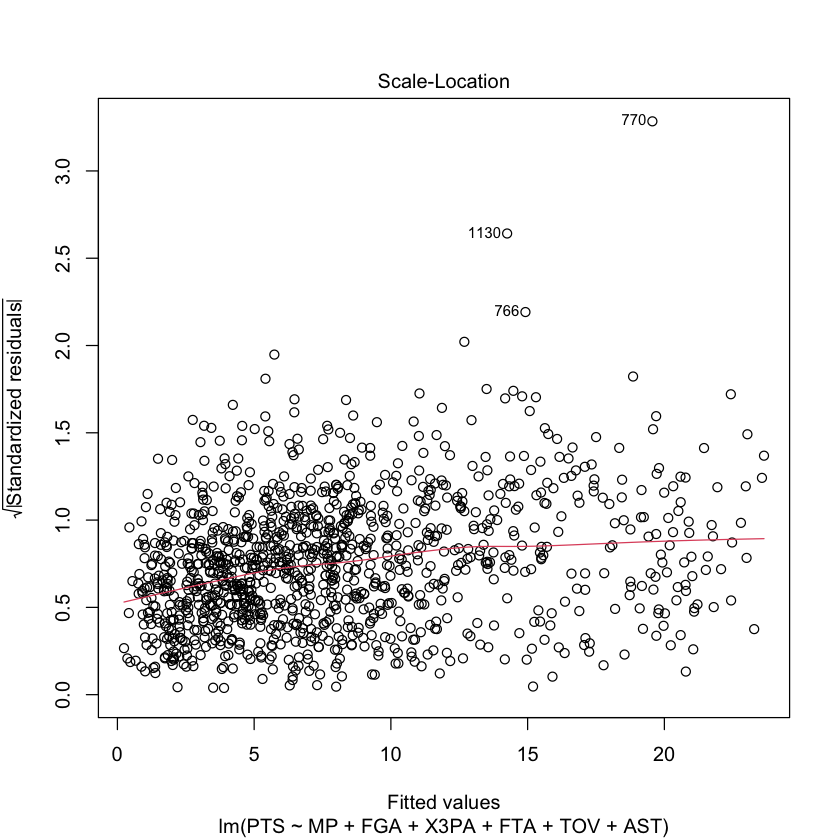

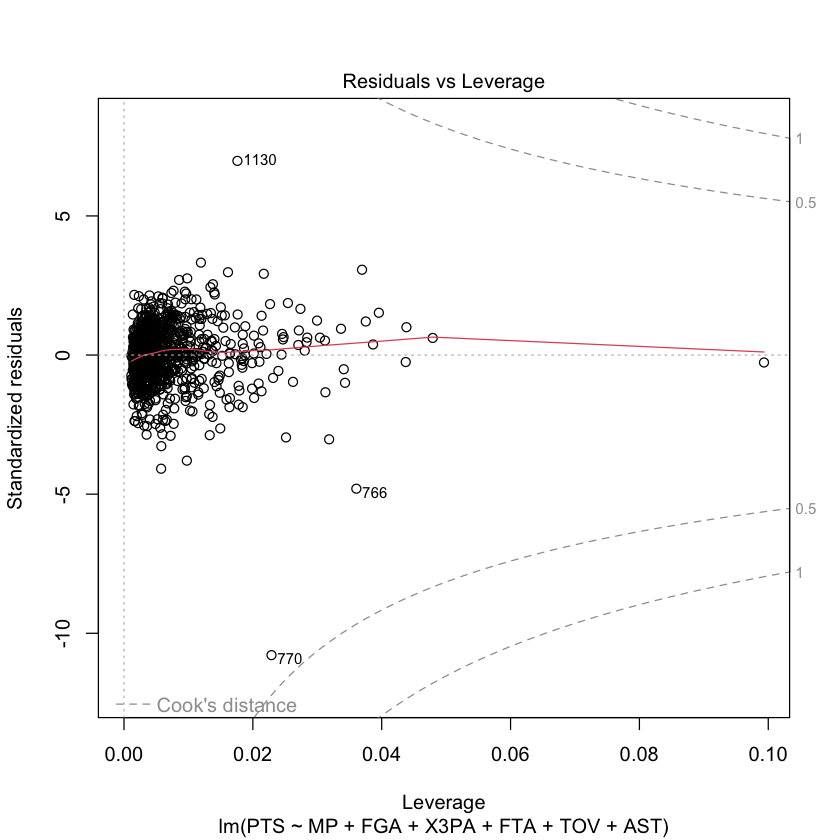

In [20]:
mod2 = lm(PTS ~ MP + FGA + X3PA + FTA + TOV + AST, data = norm.train)
summary(mod2)
# par(mfrow = c(2, 2))
plot(mod2)